# Proyecto 1 IA: prediciendo el riesgo de burnout estudiantil según el uso de IA generativa

Para este proyecto elegí trabajar con el dataset **Impact of AI on Students** de Kaggle. La idea es entrenar un modelo de clasificación que prediga el nivel de riesgo de burnout de un estudiante (bajo/medio/alto) a partir de variables como cuánto usa herramientas de IA generativa, cuánto estudia de forma "tradicional", su rendimiento académico y algunas variables de bienestar.

Elegí este tema porque me pareció más entretenido que trabajar con un dataset genérico, y porque el uso de IA en el estudio es algo que uno mismo vive día a día en la u, así que se me hizo más fácil interpretar los resultados y detectar cuando algo no calzaba.

El notebook sigue más o menos el orden que se pidió en el curso: primero exploro los datos (EDA), después armo variables nuevas (feature engineering), selecciono las más relevantes, entreno varios modelos, reviso overfitting, y al final comparo métricas y armo un resumen para el README.

Un detalle: todos los gráficos se muestran directamente en el notebook con `plt.show()`, no los guardo como imágenes aparte, para no llenar el repo de archivos que después hay que andar borrando.

## 0. Antes de meterme al código

Dejo anotadas un par de decisiones que tomé para todo el proyecto, antes de programar:

1. **Tipo de problema:** es un problema de clasificación, porque lo que quiero predecir es un nivel de riesgo (bajo/medio/alto), no un número continuo.
2. **De dónde salen los datos:** el dataset es secundario, lo bajé de Kaggle. O sea, no encuesté a nadie ni recolecté datos yo mismo, trabajo con lo que ya está publicado.
3. **Hasta dónde llegan las conclusiones:** con estos modelos puedo encontrar patrones asociados al burnout, pero eso no significa que se pueda probar que el uso de IA *causa* burnout. Para afirmar causalidad necesitaría otro diseño de estudio (por ejemplo uno longitudinal), no un dataset de corte transversal como este.

Dejo esto anotado porque me sirve de referencia más adelante, cuando interprete los resultados.

## 1. Librerías y configuración general

Acá importo todo lo que voy a usar en el notebook y dejo fijos algunos parámetros generales (semilla aleatoria, tamaño de los gráficos, etc.) para que los resultados sean reproducibles si alguien más lo corre.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

# Rutas robustas: funcionan si el notebook se ejecuta desde la raíz del proyecto
# o desde la carpeta notebooks/.
cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (root for root in root_candidates if (root / "data" / "ai_student_impact.csv").exists()),
    cwd,
)
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Directorio de métricas:", METRICS_DIR)


Raíz del proyecto: /mnt/data/proyecto_burnout_ia_entrega
Directorio de métricas: /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics


## 2. Cargar el dataset

### Cómo se organizan los datos

El dataset utilizado proviene de Kaggle y se deja en la carpeta `data/` con el nombre:

```text
data/ai_student_impact.csv
```

Esta ruta permite que el notebook sea reproducible dentro del repositorio. Además, el código usa una detección robusta de rutas para funcionar tanto si se ejecuta desde la raíz del proyecto como desde la carpeta `notebooks/`.


In [2]:
possible_paths = [
    PROJECT_ROOT / "data" / "ai_student_impact.csv",
    Path("data/ai_student_impact.csv"),
    Path("../data/ai_student_impact.csv"),
    Path("ai_student_impact.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el dataset. Guárdalo como data/ai_student_impact.csv "
        "dentro del repositorio."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset encontrado en:", DATA_PATH)
print("Dimensiones del dataset:", df.shape)
df.head()


Dataset encontrado en: /mnt/data/proyecto_burnout_ia_entrega/data/ai_student_impact.csv
Dimensiones del dataset: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 3. Primera mirada a los datos

Antes de hacer cualquier otra cosa reviso que el csv se haya cargado bien: tipos de dato, nombres de columnas, dimensiones. Esto me sirve para saber qué limpieza voy a necesitar más adelante y detectar de inmediato si algo se cargó mal.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [4]:
list(df.columns)

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

## 4. Ubicar las columnas que necesito

Un problema que tuve al principio es que el nombre exacto de las columnas cambia un poco según la versión del dataset que descargues desde Kaggle (por ejemplo `Burnout_Risk_Level` vs `Burnout_Level`). Para no tener que estar editando el código cada vez que probaba con una copia distinta, hice una función que busca la columna primero por nombre exacto y, si no la encuentra, prueba con coincidencias parciales.

La columna objetivo que espero encontrar es `Burnout_Risk_Level`.

In [5]:
def find_column(candidates, columns):
    cols = list(columns)
    for cand in candidates:
        if cand in cols:
            return cand
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for cand in candidates:
        for col in cols:
            if cand.lower() in col.lower():
                return col
    return None

TARGET_COL = find_column(["Burnout_Risk_Level", "Burnout_Risk", "Burnout_Level", "Burnout"], df.columns)
ai_usage_col = find_column(["Weekly_GenAI_Hours", "AI_Usage_Hours", "Weekly_AI_Hours", "GenAI_Hours"], df.columns)
study_hours_col = find_column(["Traditional_Study_Hours", "Study_Hours", "Weekly_Study_Hours"], df.columns)
dependency_col = find_column(["Perceived_AI_Dependency", "AI_Dependency", "Dependency"], df.columns)
gpa_before_col = find_column(["GPA_Before_AI", "GPA_Before", "Academic_Performance_Before_AI", "Previous_GPA"], df.columns)
gpa_after_col = find_column(["GPA_After_AI", "GPA_After", "Academic_Performance_After_AI", "Current_GPA"], df.columns)

print("Objetivo:", TARGET_COL)
print("Horas IA:", ai_usage_col)
print("Horas estudio:", study_hours_col)
print("Dependencia IA:", dependency_col)
print("GPA antes:", gpa_before_col)
print("GPA después:", gpa_after_col)

assert TARGET_COL is not None, "No se detectó la columna objetivo. Define TARGET_COL manualmente."

Objetivo: Burnout_Risk_Level
Horas IA: Weekly_GenAI_Hours
Horas estudio: Traditional_Study_Hours
Dependencia IA: Perceived_AI_Dependency
GPA antes: None
GPA después: None


## 5. EDA: faltantes, duplicados y distribución

Hago el análisis exploratorio antes de entrenar cualquier modelo, porque si no reviso esto puedo terminar entrenando con datos sucios sin darme cuenta. Principalmente reviso si hay valores faltantes, filas repetidas y cómo se distribuyen las variables numéricas y la variable objetivo.

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "faltantes": missing,
    "porcentaje_%": (missing / len(df) * 100).round(2)
})

missing_summary.to_csv(METRICS_DIR / "valores_faltantes.csv")
missing_summary[missing_summary["faltantes"] > 0]


,faltantes,porcentaje_%


In [7]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

print("Variables numéricas:", numeric_cols)
desc_num = df[numeric_cols].describe().T
desc_num.to_csv(METRICS_DIR / "descripcion_variables_numericas.csv")
desc_num


Variables numéricas: ['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.0,125000.500000,14433.901067,100001.000,112500.75000,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.0,3.146102,0.478854,1.183,2.83400,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.0,8.427752,8.269490,0.000,2.39000,5.800,11.720,40.000
Tool_Diversity,50000.0,2.800260,1.188020,1.000,2.00000,3.000,4.000,5.000
Traditional_Study_Hours,50000.0,11.209271,5.156426,1.000,7.56000,11.180,14.710,35.860
Perceived_AI_Dependency,50000.0,3.505360,1.820812,1.000,2.00000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.0,4.270760,2.144066,1.000,3.00000,4.000,6.000,10.000
Post_Semester_GPA,50000.0,3.349299,0.495673,1.000,3.02375,3.421,3.749,4.000
Skill_Retention_Score,50000.0,75.798125,13.281626,10.780,66.82000,76.000,85.190,100.000


### Cómo se distribuyen las variables numéricas

Con este gráfico reviso las escalas de cada variable y si hay algo raro, tipo valores extremos o distribuciones muy asimétricas que después convenga tratar.

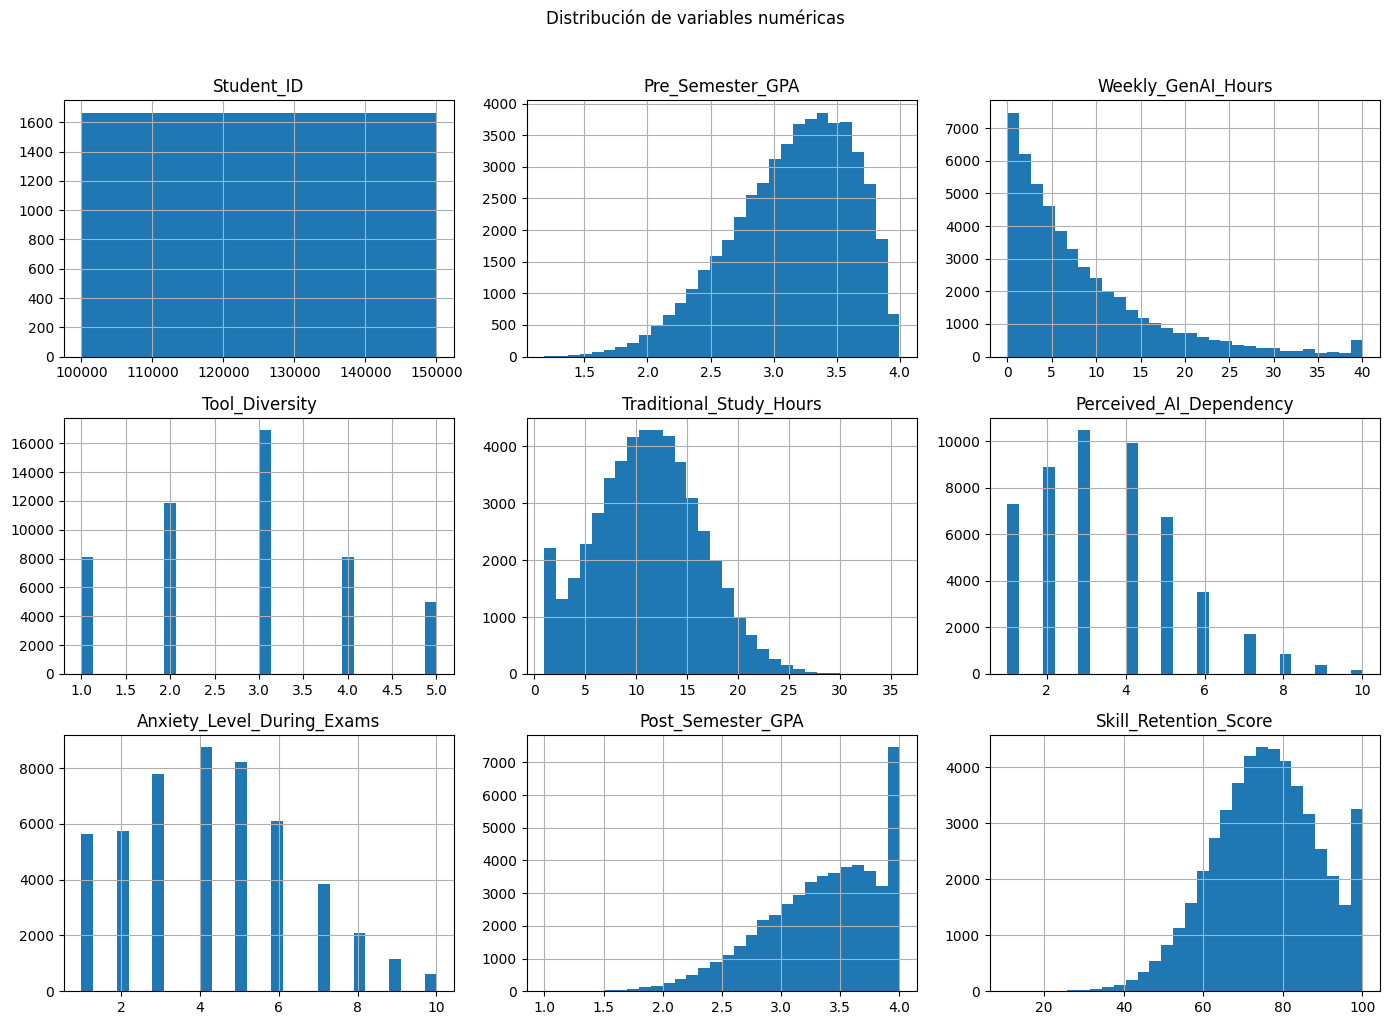

In [9]:
if numeric_cols:
    df[numeric_cols].hist(bins=30, figsize=(14, 10))
    plt.suptitle("Distribución de variables numéricas", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

### ¿Cómo se reparten las clases de burnout?

Reviso esto para ver si hay desbalance entre las clases. Si una clase tiene muchos más casos que las otras, el accuracy por sí solo puede ser engañoso, así que ya de una vez pienso en usar F1-macro más adelante en vez de quedarme solo con el accuracy.

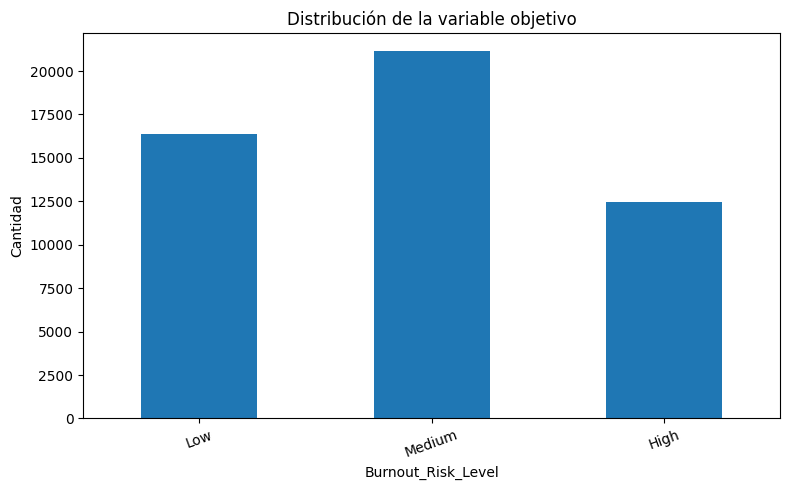

Burnout_Risk_Level
Medium    42.29
Low       32.74
High      24.97
Name: porcentaje, dtype: float64

In [10]:
def ordered_labels(values):
    preferred = ["Low", "Medium", "High", "Bajo", "Medio", "Alto"]
    unique_values = list(pd.Series(values).dropna().astype(str).unique())
    ordered = [x for x in preferred if x in unique_values]
    ordered += sorted([x for x in unique_values if x not in ordered])
    return ordered

if pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    order = None
    counts = df[TARGET_COL].value_counts().sort_index()
else:
    order = ordered_labels(df[TARGET_COL])
    counts = df[TARGET_COL].astype(str).value_counts().reindex(order).dropna()

counts.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel(TARGET_COL)
plt.ylabel("Cantidad")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close()

target_dist = (df[TARGET_COL].value_counts(normalize=True).round(4) * 100).rename("porcentaje")
target_dist.to_csv(METRICS_DIR / "distribucion_variable_objetivo.csv")
target_dist


### Correlación entre variables numéricas

Reviso la matriz de correlación para ver si hay variables muy parecidas entre sí (redundantes) o alguna relación lineal fuerte con el objetivo. Ojo que esto no prueba nada de causalidad, es solo apoyo exploratorio para pensar qué variables nuevas podrían servir.

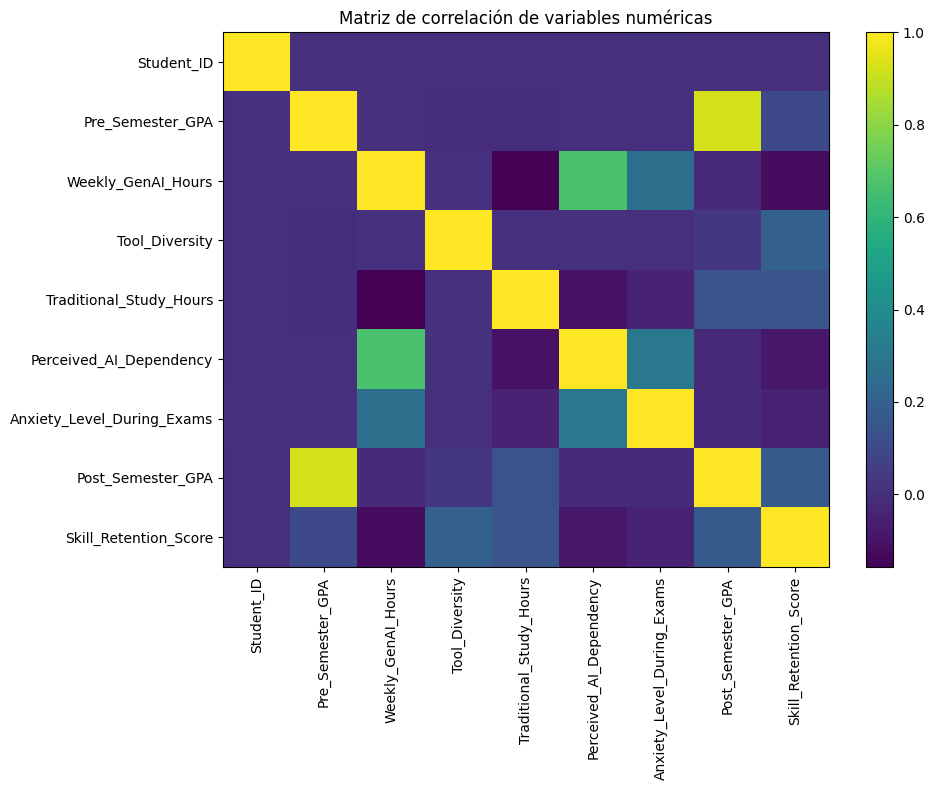

In [11]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    fig.colorbar(im, ax=ax)
    plt.title("Matriz de correlación de variables numéricas")
    plt.tight_layout()
    plt.show()
    plt.close()

## 6. Feature engineering

Acá armo algunas variables nuevas a partir de las que ya existen. Traté de que todas se puedan calcular con información que existiría *antes* de saber el resultado (o sea, sin usar la variable objetivo ni nada que la filtre), para no meter fuga de datos sin querer.

Las variables que agrego son:
- Ratio entre horas de uso de IA y horas de estudio tradicional.
- Un indicador de si el uso de IA es "intensivo" (por sobre la mediana).
- Un indicador de dependencia alta de IA.
- La diferencia entre el GPA antes y después de usar IA, solo si el dataset trae ambas columnas.

In [12]:
if pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    # Si el target fuese numérico, lo transformaría en 3 niveles. En este dataset
    # ya viene como categórico: Low, Medium y High.
    bins_burnout = pd.qcut(df[TARGET_COL], q=3, duplicates="drop")
    etiquetas_posibles = ["Bajo", "Medio", "Alto"]
    n_bins = bins_burnout.cat.categories.size
    df["target_burnout"] = bins_burnout.cat.rename_categories(etiquetas_posibles[:n_bins])
else:
    df["target_burnout"] = df[TARGET_COL].astype(str)

# Corrección mínima: eliminar identificadores reales como Student_ID, sin borrar
# columnas válidas como Paid_Subscription, que contiene la secuencia "id" en su nombre.
id_cols = [c for c in df.columns if c.lower() in ["id", "student_id"] or c.lower().endswith("_id")]
drop_cols = list(dict.fromkeys(id_cols + [TARGET_COL, "target_burnout"]))
X = df.drop(columns=drop_cols)
y = df["target_burnout"]

if ai_usage_col in df.columns and study_hours_col in df.columns:
    X["ratio_ia_estudio"] = (df[ai_usage_col] / df[study_hours_col].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    X["ratio_ia_estudio"] = X["ratio_ia_estudio"].fillna(X["ratio_ia_estudio"].median())

if ai_usage_col in df.columns:
    X["uso_intensivo_ia"] = (df[ai_usage_col] > df[ai_usage_col].median()).astype(int)

if dependency_col in df.columns and pd.api.types.is_numeric_dtype(df[dependency_col]):
    X["dependencia_ia_alta"] = (df[dependency_col] >= df[dependency_col].quantile(0.75)).astype(int)

# Corrección mínima: el dataset real usa Pre_Semester_GPA y Post_Semester_GPA.
if gpa_before_col in df.columns and gpa_after_col in df.columns:
    if pd.api.types.is_numeric_dtype(df[gpa_before_col]) and pd.api.types.is_numeric_dtype(df[gpa_after_col]):
        X["delta_gpa"] = df[gpa_after_col] - df[gpa_before_col]

# Decisión práctica: el EDA usa los 50.000 registros, pero el entrenamiento se realiza
# con una muestra estratificada para que el notebook sea reproducible en computadores
# personales y no demore demasiado. La muestra mantiene la proporción de clases.
MODEL_SAMPLE_SIZE = min(15000, len(X))
if len(X) > MODEL_SAMPLE_SIZE:
    X_model, _, y_model, _ = train_test_split(
        X, y, train_size=MODEL_SAMPLE_SIZE, stratify=y, random_state=RANDOM_STATE
    )
else:
    X_model, y_model = X.copy(), y.copy()

resumen_proceso = pd.DataFrame({
    "metrica": [
        "filas_dataset", "columnas_originales", "objetivo", "gpa_antes", "gpa_despues",
        "drop_cols", "X_shape_original", "X_shape_modelado"
    ],
    "valor": [
        len(df), df.shape[1], TARGET_COL, gpa_before_col, gpa_after_col,
        ", ".join(drop_cols), str(X.shape), str(X_model.shape)
    ]
})
resumen_proceso.to_csv(METRICS_DIR / "resumen_dataset_y_proceso.csv", index=False)

print("Columnas eliminadas:", drop_cols)
print("X original:", X.shape, "y original:", y.shape)
print("X usado para modelado:", X_model.shape, "y usado para modelado:", y_model.shape)
X_model.head()


Columnas eliminadas: ['Student_ID', 'Burnout_Risk_Level', 'target_burnout']
X original: (50000, 17) y original: (50000,)
X usado para modelado: (15000, 17) y usado para modelado: (15000,)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,ratio_ia_estudio,uso_intensivo_ia,dependencia_ia_alta
2077,Humanities,Senior,3.080,3.66,Copywriting/Drafting,Advanced,3,True,9.74,5,Allowed_With_Citation,2,3.385,81.48,0.375770,0,1
38689,STEM,Freshman,3.413,25.78,Ideation,Intermediate,4,False,15.73,6,Actively_Encouraged,10,3.668,77.83,1.638907,1,1
45991,Medical,Senior,2.858,3.80,Debugging/Troubleshooting,Advanced,4,False,21.95,2,Allowed_With_Citation,4,3.447,100.00,0.173121,0,0
28250,STEM,Sophomore,3.511,2.69,Copywriting/Drafting,Intermediate,2,True,12.60,2,Actively_Encouraged,4,3.979,100.00,0.213492,0,0
32655,Medical,Graduate,2.816,8.73,Debugging/Troubleshooting,Advanced,5,False,10.18,5,Actively_Encouraged,6,3.331,97.07,0.857564,1,1


In [13]:
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Numéricas:", num_features)
print("Categóricas:", cat_features)

Numéricas: ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'ratio_ia_estudio', 'uso_intensivo_ia', 'dependencia_ia_alta']
Categóricas: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy']


## 7. Separar train/test y preprocesar

### Por qué estratifico el split

Uso `train_test_split` con `stratify=y` para que la proporción de cada clase de burnout se mantenga parecida en train y en test. Si no estratifico, con clases desbalanceadas puede pasar que el test quede casi puros ejemplos de una sola clase, y ahí las métricas no dirían mucho.

Todo el preprocesamiento (imputación, escalado, codificación) lo meto dentro de un `Pipeline` con `ColumnTransformer`. La razón es evitar fuga de información: los parámetros de escalado/imputación se calculan solo con el train y después se aplican al test, nunca al revés.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, stratify=y_model, random_state=RANDOM_STATE
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))


X_train: (12000, 17) X_test: (3000, 17)
target_burnout
Medium    0.423
Low       0.327
High      0.250
Name: proportion, dtype: float64


### Preprocesamiento y selección de variables

Las variables numéricas las imputo con la mediana y las escalo, porque modelos como KNN y regresión logística son sensibles a la escala de los datos. Las categóricas las imputo con la categoría más frecuente y las paso por One-Hot Encoding.

Uso `sparse_output=False` en el OneHotEncoder (y `sparse_threshold=0` en el ColumnTransformer) porque más adelante uso GaussianNB, que necesita matrices densas y no dispersas.

Después de transformar las variables, aplico `SelectKBest` con información mutua para quedarme solo con un subconjunto de las variables transformadas más relevantes, en vez de meterlas todas al modelo.

In [15]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    sparse_threshold=0,
)

X_train_tmp = preprocessor.fit_transform(X_train, y_train)
K_FEATURES = min(30, X_train_tmp.shape[1])
print("Variables transformadas:", X_train_tmp.shape[1])
print("Variables seleccionadas:", K_FEATURES)

def mi_score(X_data, y_data):
    return mutual_info_classif(X_data, y_data, random_state=RANDOM_STATE)

selector = SelectKBest(score_func=mi_score, k=K_FEATURES)
selector_preview = SelectKBest(score_func=mi_score, k=K_FEATURES).fit(X_train_tmp, y_train)
feature_names = preprocessor.get_feature_names_out()
mi_series = pd.Series(selector_preview.scores_, index=feature_names).sort_values(ascending=False)
mi_series.head(20).to_csv(METRICS_DIR / "feature_selection_mutual_info_top20.csv")
mi_series.head(20)

Variables transformadas: 34
Variables seleccionadas: 30


num__Weekly_GenAI_Hours                            0.128200
num__ratio_ia_estudio                              0.087524
num__Perceived_AI_Dependency                       0.070310
num__uso_intensivo_ia                              0.058472
num__dependencia_ia_alta                           0.048554
num__Anxiety_Level_During_Exams                    0.019588
num__Traditional_Study_Hours                       0.013985
cat__Year_of_Study_Freshman                        0.013431
cat__Prompt_Engineering_Skill_Beginner             0.010275
num__Pre_Semester_GPA                              0.009708
cat__Year_of_Study_Graduate                        0.009181
cat__Prompt_Engineering_Skill_Intermediate         0.008948
num__Post_Semester_GPA                             0.006962
cat__Major_Category_Humanities                     0.005913
cat__Year_of_Study_Junior                          0.005536
cat__Primary_Use_Case_Direct_Answer_Generation     0.004862
cat__Primary_Use_Case_Copywriting/Drafti

## 8. Entrenar y comparar modelos

### Qué modelos elegí y por qué

Elegí modelos revisados en clase y adecuados para clasificación:

- **Regresión logística**: línea base interpretable.
- **KNN**: modelo basado en similitud entre estudiantes.
- **Decision Tree**: modelo interpretable mediante reglas.
- **Random Forest**: ensamble de árboles, útil para capturar relaciones no lineales.
- **Naive Bayes**: comparación rápida y simple.

Para controlar el sobreajuste sin hacer que el notebook demore demasiado, uso hiperparámetros simples y comparo el desempeño en train contra test. En KNN uso una submuestra estratificada de entrenamiento, porque este modelo calcula distancias y se vuelve muy costoso con 50.000 registros.


In [16]:
models = {
    "Regresión logística": LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Naive Bayes": GaussianNB(),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("selector", selector), ("model", model)])
    for name, model in models.items()
}

best_pipelines = {}
param_rows = []

# Submuestra estratificada solo para KNN, por costo computacional de distancias.
knn_train_size = min(5000, len(X_train))
X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train,
    y_train,
    train_size=knn_train_size,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

for name, pipe in pipelines.items():
    print(f"Entrenando {name}...")
    if name == "KNN":
        pipe.fit(X_train_knn, y_train_knn)
        datos_entrenamiento = f"submuestra estratificada de {knn_train_size} casos"
    else:
        pipe.fit(X_train, y_train)
        datos_entrenamiento = "conjunto de entrenamiento completo de la muestra de modelado"
    best_pipelines[name] = pipe
    param_rows.append({
        "Modelo": name,
        "Datos de entrenamiento": datos_entrenamiento,
        "Parámetros": str(pipe.named_steps["model"].get_params()),
    })

param_df = pd.DataFrame(param_rows)
param_df.to_csv(METRICS_DIR / "parametros_modelos.csv", index=False)
param_df[["Modelo", "Datos de entrenamiento", "Parámetros"]]


Entrenando Regresión logística...


Entrenando KNN...


Entrenando Decision Tree...


Entrenando Random Forest...


Entrenando Naive Bayes...


,Modelo,Datos de entrenamiento,Parámetros
0,Regresión logística,conjunto de entrenamiento completo de la muest...,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
1,KNN,submuestra estratificada de 5000 casos,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
2,Decision Tree,conjunto de entrenamiento completo de la muest...,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
3,Random Forest,conjunto de entrenamiento completo de la muest...,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
4,Naive Bayes,conjunto de entrenamiento completo de la muest...,"{'priors': None, 'var_smoothing': 1e-09}"


### ¿Hay overfitting?

Comparo el F1-macro en train contra el de test para cada modelo. Si la diferencia es muy grande, es señal de que el modelo se aprendió el train de memoria y no está generalizando bien a datos que no ha visto.

In [17]:
# Para no hacer muy costosa la evaluación train de KNN, calculo el F1 de train
# sobre una submuestra estratificada. El test sí se evalúa completo.
train_eval_size = min(5000, len(X_train))
X_train_eval, _, y_train_eval, _ = train_test_split(
    X_train,
    y_train,
    train_size=train_eval_size,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

overfit_rows = []
for name, pipe in best_pipelines.items():
    y_pred_train = pipe.predict(X_train_eval)
    y_pred_test = pipe.predict(X_test)
    f1_train = f1_score(y_train_eval, y_pred_train, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
    overfit_rows.append({
        "Modelo": name,
        "F1 macro train": round(f1_train, 4),
        "F1 macro test": round(f1_test, 4),
        "Brecha F1 train-test": round(f1_train - f1_test, 4),
    })

overfit_df = pd.DataFrame(overfit_rows).sort_values("Brecha F1 train-test", ascending=False)
overfit_df.to_csv(METRICS_DIR / "overfitting.csv", index=False)
overfit_df


,Modelo,F1 macro train,F1 macro test,Brecha F1 train-test
3,Random Forest,0.6247,0.5279,0.0968
2,Decision Tree,0.5570,0.5100,0.0470
1,KNN,0.4720,0.4498,0.0223
0,Regresión logística,0.5090,0.5135,-0.0044
4,Naive Bayes,0.4988,0.5072,-0.0084


## 9. Evaluación final

### Qué métricas uso y por qué

Como el problema tiene 3 clases, no me quedo solo con el accuracy: reporto también precision, recall y F1, todas en su versión macro (le dan el mismo peso a cada clase, sin importar cuántos ejemplos tenga cada una). Uso F1-macro como criterio principal para elegir el mejor modelo, porque me parece la métrica más equilibrada cuando hay desbalance entre los niveles de burnout.

In [18]:
results_rows = []
predictions = {}

for name, pipe in best_pipelines.items():
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    results_rows.append({
        "Modelo": name,
        "Accuracy test": round(accuracy_score(y_test, y_pred), 4),
        "Precision macro test": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall macro test": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "F1-score macro test": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
    })

results_df = pd.DataFrame(results_rows).sort_values("F1-score macro test", ascending=False)
results_df.to_csv(METRICS_DIR / "metricas_modelos.csv", index=False)
results_df

,Modelo,Accuracy test,Precision macro test,Recall macro test,F1-score macro test
3,Random Forest,0.5233,0.5277,0.5471,0.5279
0,Regresión logística,0.5127,0.5144,0.5419,0.5135
2,Decision Tree,0.5030,0.5103,0.5212,0.5100
4,Naive Bayes,0.5083,0.5246,0.5239,0.5072
1,KNN,0.4563,0.4645,0.4441,0.4498


In [19]:
best_model_name = results_df.iloc[0]["Modelo"]
best_pipe = best_pipelines[best_model_name]
print("Mejor modelo según F1-score macro en test:", best_model_name)
report = classification_report(y_test, predictions[best_model_name], zero_division=0)
print(report)
(METRICS_DIR / "classification_report_mejor_modelo.txt").write_text(f"Mejor modelo: {best_model_name}\n\n{report}", encoding="utf-8")

Mejor modelo según F1-score macro en test: Random Forest
              precision    recall  f1-score   support

        High       0.57      0.61      0.59       749
         Low       0.50      0.68      0.58       982
      Medium       0.51      0.35      0.42      1269

    accuracy                           0.52      3000
   macro avg       0.53      0.55      0.53      3000
weighted avg       0.52      0.52      0.51      3000



409

### Matriz de confusión

Con esto reviso puntualmente en qué clases se equivoca más el mejor modelo (por ejemplo, si confunde seguido "medio" con "alto").

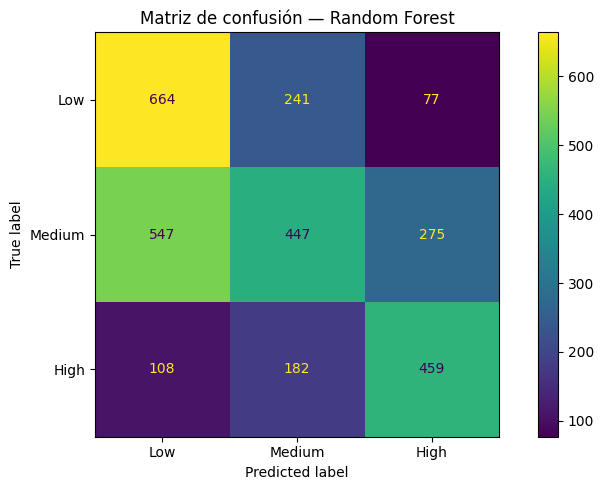

,Low,Medium,High
Low,664,241,77
Medium,547,447,275
High,108,182,459


In [20]:
labels = ordered_labels(y_test)
cm = confusion_matrix(y_test, predictions[best_model_name], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(METRICS_DIR / "matriz_confusion_mejor_modelo.csv")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title(f"Matriz de confusión — {best_model_name}")
plt.tight_layout()
plt.show()
plt.close()

cm_df


### ROC-AUC (complementaria)

Calculo esto solo si el modelo permite sacar probabilidades (`predict_proba`). La dejo como métrica extra, pero para elegir el mejor modelo me sigo basando en el F1-macro porque es más directo de interpretar en un problema multiclase.

In [21]:
if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    try:
        y_score = best_pipe.predict_proba(X_test)
        labels_auc = best_pipe.named_steps["model"].classes_
        auc = roc_auc_score(y_test, y_score, labels=labels_auc, multi_class="ovr", average="macro")
        text_auc = f"ROC-AUC macro OVR — {best_model_name}: {auc:.4f}"
        print(text_auc)
        (METRICS_DIR / "roc_auc_mejor_modelo.txt").write_text(text_auc, encoding="utf-8")
    except Exception as e:
        print("No fue posible calcular ROC-AUC:", e)
else:
    print("El mejor modelo no soporta predict_proba; se omite ROC-AUC.")


ROC-AUC macro OVR — Random Forest: 0.7168


## 10. Qué variables importan más, y una mirada con PCA

Uso la importancia de variables de Random Forest para ver qué predictores están aportando más al modelo. Además hago un PCA a 2 componentes, pero solo para visualizar cómo se separan (o no) las clases en un espacio reducido; no lo uso como modelo predictivo, es más que nada para entender un poco mejor la estructura de los datos.

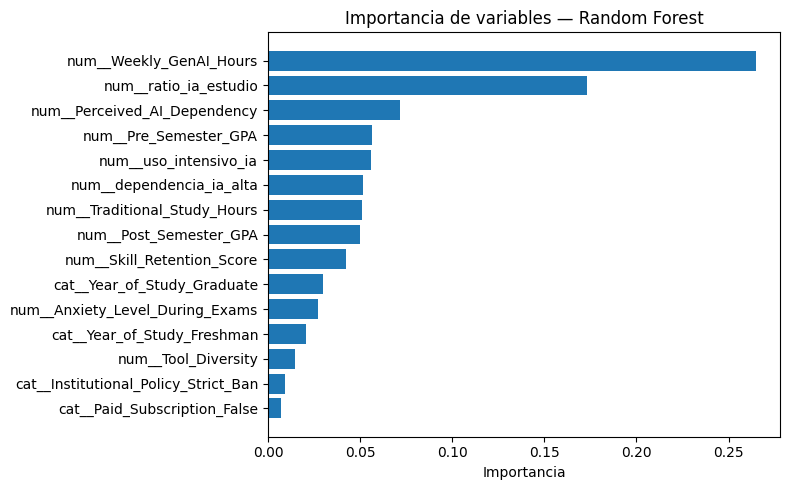

,Variable,Importancia
1,num__Weekly_GenAI_Hours,0.264665
8,num__ratio_ia_estudio,0.173177
4,num__Perceived_AI_Dependency,0.071815
0,num__Pre_Semester_GPA,0.056511
9,num__uso_intensivo_ia,0.056077
10,num__dependencia_ia_alta,0.051778
3,num__Traditional_Study_Hours,0.051184
6,num__Post_Semester_GPA,0.049848
7,num__Skill_Retention_Score,0.042557
14,cat__Year_of_Study_Graduate,0.030018


In [22]:
rf_pipe = best_pipelines["Random Forest"]
all_feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
selected_feature_names = all_feature_names[rf_pipe.named_steps["selector"].get_support()]
importances = rf_pipe.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({"Variable": selected_feature_names, "Importancia": importances}).sort_values("Importancia", ascending=False)
importance_df.to_csv(METRICS_DIR / "importancia_variables_random_forest.csv", index=False)

top = importance_df.head(15).sort_values("Importancia")
plt.barh(top["Variable"], top["Importancia"])
plt.title("Importancia de variables — Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()
plt.close()

importance_df.head(15)

Varianza explicada acumulada: 0.3489


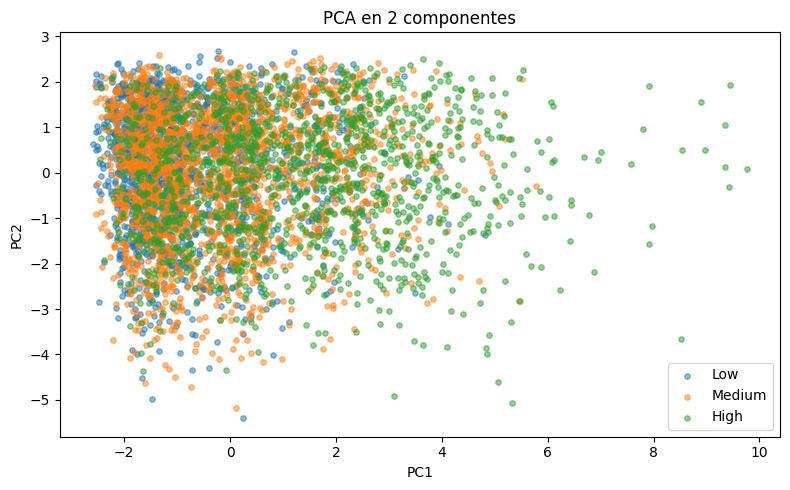

In [23]:
# Uso una muestra para visualizar PCA de forma liviana y legible.
pca_plot_size = min(5000, len(X_train))
X_train_pca_base, _, y_train_pca_base, _ = train_test_split(
    X_train,
    y_train,
    train_size=pca_plot_size,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_train_prep = preprocessor.fit_transform(X_train_pca_base, y_train_pca_base)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)
varianza_pca = round(pca.explained_variance_ratio_.sum(), 4)
print("Varianza explicada acumulada:", varianza_pca)
(METRICS_DIR / "varianza_pca.txt").write_text(str(varianza_pca), encoding="utf-8")

pca_df = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"])
pca_df["burnout"] = y_train_pca_base.values
for label in ordered_labels(pca_df["burnout"]):
    subset = pca_df[pca_df["burnout"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], label=label, alpha=0.5, s=15)
plt.legend()
plt.title("PCA en 2 componentes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()
plt.close()


### Comparando todos los modelos en un gráfico

Este gráfico junta las métricas de todos los modelos para que sea más fácil comparar de un vistazo cuál rindió mejor en el test.

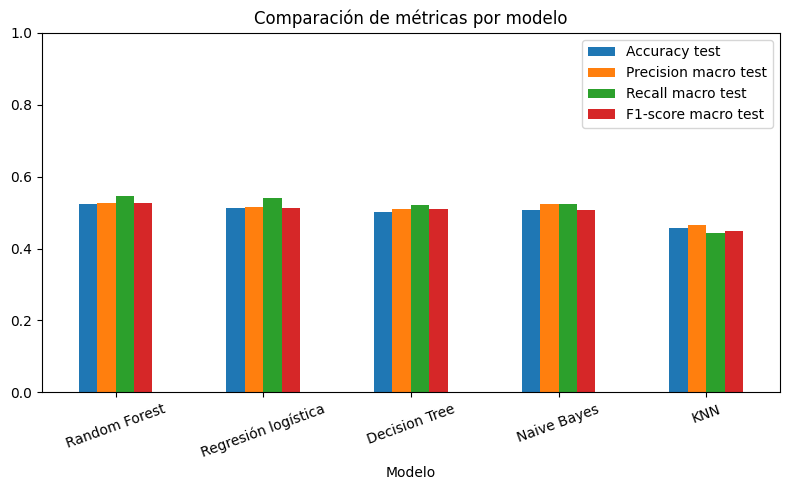

In [24]:
metrics_to_plot = ["Accuracy test", "Precision macro test", "Recall macro test", "F1-score macro test"]
plot_df = results_df.set_index("Modelo")[metrics_to_plot]
plot_df.plot(kind="bar")
plt.title("Comparación de métricas por modelo")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
plt.close()

## 11. Armar un resumen para el README

Esta última parte genera un resumen en texto con las métricas, el chequeo de overfitting y algunas conclusiones, y lo guarda como un `.md`. La idea es poder pegarlo directamente en el `README.md` del repositorio del repositorio. Las imágenes no las guardo aparte, quedan solo dentro del notebook ya ejecutado.

In [25]:
def df_to_markdown_simple(df_in):
    cols = list(df_in.columns)
    lines = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in df_in.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)

best_row = results_df.iloc[0]
features_text = ", ".join(importance_df.head(5)["Variable"].astype(str).tolist())
summary_text = f"""## Resultados obtenidos

La tabla siguiente resume el desempeño de los modelos en el conjunto de test:

{df_to_markdown_simple(results_df)}

El mejor modelo según F1-score macro fue **{best_model_name}**, con F1-score macro de **{best_row['F1-score macro test']}** y accuracy de **{best_row['Accuracy test']}**.

### Control de overfitting

{df_to_markdown_simple(overfit_df)}

### Variables más relevantes

Según Random Forest, las variables transformadas más relevantes fueron: **{features_text}**.

### PCA

La varianza explicada acumulada por las dos primeras componentes fue **{varianza_pca}**.

## Conclusiones

El modelo con mejor desempeño fue **{best_model_name}**. Esto sugiere que las variables de uso de IA, hábitos de estudio, desempeño académico y bienestar contienen información útil para clasificar el riesgo de burnout estudiantil. La evaluación se basó especialmente en F1-score macro, ya que permite comparar el rendimiento considerando todas las clases de riesgo.

Los resultados deben interpretarse como asociaciones predictivas y no como causalidad. El análisis depende de la calidad del dataset, de posibles sesgos de autorreporte y de la representatividad de los registros. Como mejoras futuras, se recomienda probar validación externa, estudiar grupos por carrera o año académico y complementar el análisis con técnicas de interpretabilidad.
"""

summary_path = METRICS_DIR / "resumen_readme.md"
summary_path.write_text(summary_text, encoding="utf-8")
print("Resumen de resultados guardado en:", summary_path)
print(summary_text)


Resumen de resultados guardado en: /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/resumen_readme.md
## Resultados obtenidos

La tabla siguiente resume el desempeño de los modelos en el conjunto de test:

| Modelo | Accuracy test | Precision macro test | Recall macro test | F1-score macro test |
| --- | --- | --- | --- | --- |
| Random Forest | 0.5233 | 0.5277 | 0.5471 | 0.5279 |
| Regresión logística | 0.5127 | 0.5144 | 0.5419 | 0.5135 |
| Decision Tree | 0.503 | 0.5103 | 0.5212 | 0.51 |
| Naive Bayes | 0.5083 | 0.5246 | 0.5239 | 0.5072 |
| KNN | 0.4563 | 0.4645 | 0.4441 | 0.4498 |

El mejor modelo según F1-score macro fue **Random Forest**, con F1-score macro de **0.5279** y accuracy de **0.5233**.

### Control de overfitting

| Modelo | F1 macro train | F1 macro test | Brecha F1 train-test |
| --- | --- | --- | --- |
| Random Forest | 0.6247 | 0.5279 | 0.0968 |
| Decision Tree | 0.557 | 0.51 | 0.047 |
| KNN | 0.472 | 0.4498 | 0.0223 |
| Regresión logística | 0.509 | 0.5135 | -

In [26]:
print("Métricas y resúmenes generados:")
for p in sorted(METRICS_DIR.glob("*")):
    if p.is_file():
        print("-", p)

print("\nNota: los gráficos no se guardan como imágenes; se muestran directamente en el notebook.")

Métricas y resúmenes generados:
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/classification_report_mejor_modelo.txt
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/descripcion_variables_numericas.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/distribucion_variable_objetivo.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/feature_selection_mutual_info_top20.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/importancia_variables_random_forest.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/matriz_confusion_mejor_modelo.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/metricas_modelos.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/overfitting.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/parametros_modelos.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/resumen_dataset_y_proceso.csv
- /mnt/data/proyecto_burnout_ia_entrega/outputs/metrics/resumen_readme.md
- /mnt/data/proyecto